<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lesson_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 3.4 (Non-Linear Growth Model) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Recap: Simulation Setup](#Setup)

4.  [Non-Linear Change Functions](#Nonlinear)

5.  [Polynomial Growth](#Polynomial)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Recap: Population Data </b> </font>


<p align = 'justify'>
Our world population data has two columns: one holds data that has been estimated by the U.S. Census Bureau, and one holds data gathered by the United Nations. The data is listed from years 1950 to 2016. The values are in billions.
</p>

In [1]:
##=============================================================================================##
## Import Libraries:                                                                           ##
##=============================================================================================##

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display_html
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

##=============================================================================================##
## Import the Data:                                                                            ##
##=============================================================================================##

# Define the file we want to import

address = 'https://github.com/MAugspurger/ModSimPy_MAugs/raw/main/'
file_loc = 'Images_and_Data/Data/World_pop_data.xlsx'

# Import the world population data
data = pd.read_excel(address + file_loc, header=0,index_col=0)

##=============================================================================================##
## Display the Data:                                                                           ##
##=============================================================================================##

display(data.head())

,US_census,UN
Year,,
1950,2.557629,2.525149
1951,2.594940,2.572851
1952,2.636772,2.619292
1953,2.682053,2.665865
1954,2.730228,2.713172


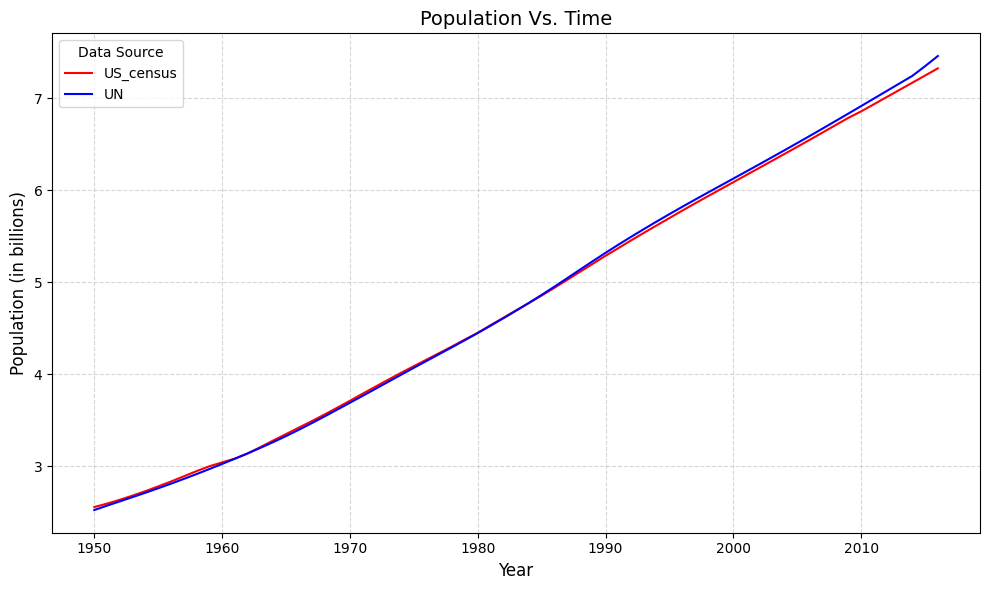

In [2]:
##=============================================================================================##
## Plot the Data:                                                                              ##
##=============================================================================================##

ax = data.plot(
    kind    = 'line',
    y       = ['US_census', 'UN'],
    color   = ['red', 'blue'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Population Vs. Time", fontsize = 14)

ax.set_xlabel("Year", fontsize = 12)

ax.set_ylabel("Population (in billions)", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha = 0.5)

plt.legend(title = "Data Source")

plt.tight_layout()

# Display the plot:

plt.show()

<center>$\rule$</center>

<font size = 5> <b> 2.2 Define Useful Functions </b> </font>

In [3]:
#@title This cell defines the functions: display_dataframes, create_model, display_model, and plot_data

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    html_df = pd.DataFrame(df).head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  create_model                                                                     ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def create_model(X, y, name, bias_on = True):

  ##===========================================================================================##
  ## Use a LinearRegression Object to Find the Best Fit for the Model:                         ##
  ##===========================================================================================##

  # Create a LinearRegression object with a forced-origin intercept:

  model = LinearRegression(fit_intercept = bias_on)

  # Fit the LinearRegression objects to the features and target:

  model.fit(X, y)

  # Get the coefficient and bias for the model:

  coefs = np.round(model.coef_[0], 2)
  bias  = np.round(model.intercept_, 2)

  ##===========================================================================================##
  ## Get The Model Predictions:                                                                ##
  ##===========================================================================================##

  predictions = model.predict(X)

  ##===========================================================================================##
  ## Calculate Model Losses:                                                                   ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, predictions))

  ##===========================================================================================##
  ## Create a DataFrame to Store the Model's Results and Predictions:                          ##
  ##===========================================================================================##

  # Create the results DataFrame:

  results_df = pd.DataFrame({"Name": name, "Coefs": [coefs], "Bias": bias, "Loss": loss})

  # Create the predictions DataFrame:

  predictions_df = pd.DataFrame({"Target": X.iloc[:, 0]})

  predictions_df["Predictions"] = predictions

  ##===========================================================================================##
  ## Return the Model's Results and Predictions:                                               ##
  ##===========================================================================================##

  return results_df, predictions_df

##=============================================================================================##
## Function:  display_models                                                                   ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            trunc      - Number of decimals to display for numbers (optional, default = 3)   ##
##            n_items    - Number of items to display (optional, default = 5)                  ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coef_list, bias_list, loss_list, title, trunc = 3, n_items = 5):

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  for i in range (0, len(model_list)):

    coef_list[i] = np.round(coef_list[i], trunc)
    bias_list[i] = np.round(bias_list[i], trunc)
    loss_list[i] = np.round(loss_list[i], trunc)

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coef_list

  # Add the model biases:

  results["Bias"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title], n_items)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(model_list[i]["Target"], model_list[i]["Predictions"], color = color_list[i],
               label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[-1]["Predictions"] + error

    # Create the error- model:

    model_minus_error = model_list[-1]["Predictions"] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': model_list[0]["Target"],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

<center>$\rule$</center>

<font size = 5> <b> 2.3 Data Cleaning </b> </font>

In [4]:
##=============================================================================================##
## Clean the Data and Separate Features and Targets:                                           ##
##=============================================================================================##

# Remove any rows missing data:

cleaned_data = data.reset_index().dropna()

# Identify the feature data:

X = pd.DataFrame(cleaned_data["Year"])

# Identify the target data:

y = pd.DataFrame(cleaned_data["US_census"])

##=============================================================================================##
## Display the Full Dataset, Feature Data, and Target Data:                                    ##
##=============================================================================================##

# Display the feature and target data:

display_dataframes([cleaned_data, X, y], ["Full Dataset", "Feature Data", "Target Data"])

Full Dataset 
 
 
 
 Year 
 US_census 
 UN 
 
 
 
 
 0 
 1950 
 2.557629 
 2.525149 
 
 
 1 
 1951 
 2.594940 
 2.572851 
 
 
 2 
 1952 
 2.636772 
 2.619292 
 
 
 3 
 1953 
 2.682053 
 2.665865 
 
 
 4 
 1954 
 2.730228 
 2.713172 
 
 
 Feature Data 
 
 
 
 Year 
 
 
 
 
 0 
 1950 
 
 
 1 
 1951 
 
 
 2 
 1952 
 
 
 3 
 1953 
 
 
 4 
 1954 
 
 
 Target Data 
 
 
 
 US_census 
 
 
 
 
 0 
 2.557629 
 
 
 1 
 2.594940 
 
 
 2 
 2.636772 
 
 
 3 
 2.682053 
 
 
 4 
 2.730228

[Return to Top](#Notebook-Start)

<a name="Setup"></a>

---

<font size = 6> <b> 3. Recap: Simulation Setup</b> </font>

---

Even though, we can tell that the linear model isn't the best fit for the data, let's keep with it for now to remind ourselves how we set up the simulation in the last lesson.

<font size = 5> <b> 3.1 Define State Object </b> </font>

In [5]:
##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

initial_state = pd.Series({
    "Population" : y.iloc[0].values[0],
    "Year"       : X.iloc[0].values[0]
})

initial_state.name = 'population'

display_dataframes([initial_state],["Initial State"])

,population
Population,2.557629
Year,1950.000000


<center>$\rule$</center>

<font size = 5> <b> 3.2 Define Simulation Parameters </b> </font>

In [20]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the end year:

end_year = X.iloc[-1].values[0]

# Step Size:

step_size = 1 # year

# Coefficients:

coeffs = [0.069293]

# Store the parameters in a dictionary:

parameters_linear_time = pd.Series({
    "End Year"     : end_year,
    "Step Size"    : step_size,
    "Coefficients" : coeffs
})

# Rename the columns:

parameters.name = 'Value'

parameters.index.name = "Parameter"

# Display the Parameters:

display_dataframes([parameters],["Parameters"])

,Value
Parameter,
End Year,2016
Step Size,1
Coefficients,[0.069293]


<center>$\rule$</center>

<font size = 5> <b> 3.3 Create A Change Function </b> </font>

In [25]:
##=============================================================================================##
## Define the Linear Change Function:                                                          ##
##=============================================================================================##

# This function updates the population linearly based on time step size.

def cf_linear_time(state, cf_params, step_size):

  # Unpack the parameters:

  growth_rate = cf_params.loc['Coefficients'][0]

  # Update the ball's velocity, based on the acceleration and the size of the time step:

  state['Population'] += growth_rate * step_size

  # Update the simulation time:

  state['Year'] += step_size

  # Return the updated system state:

  return state

<center>$\rule$</center>

<font size = 5> <b> 3.3 Create A Run_Simulation Function </b> </font>

We are making a change to the definition of the `run_simulation` definition that we used in the last lesson. In this version, we are requiring the change function to be supplied as an input. This will allow us to quickly and easily swap out different types of change function to test them.

In [26]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters, initial_state, change_function):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end year:

  end_year = parameters.loc['End Year']

  # Get the step size:

  step_size = parameters.loc['Step Size']

  # Get the change function parameters:

  cf_params = pd.Series({'Coefficients' : parameters.loc['Coefficients']})

  # Calculate the number of simulation steps:

  n_steps = int((end_year - initial_state['Year']) / step_size)

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'World Population Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(n_steps):

    # Get the state of the system for the current time step:

    state = change_function(state, cf_params, step_size)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

<center>$\rule$</center>

<font size = 5> <b> 3.3 Create An Analyze_Simulation Function </b> </font>

In [27]:
##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation(state_history, X, y, plot_data = False, display_data = False):

  ##===========================================================================================##
  ## Compute the Simulation Loss:                                                              ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, simulation_history['Population']))

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display_data == True):

    # Create DataFrame to display the simulation loss:

    loss_df = pd.Series({"RMSE (Billion People)" : np.round(loss, 2)}).to_frame().T

    # Recombine the target and feature data:

    data = pd.concat([y, X], axis = 1)

    # Create a Dataframe containing the Real and Simulated Data:

    combined_df = pd.concat([y, state_history['Population'], X], axis = 1).dropna()

    combined_df.rename(columns = {'US_census' : 'Real Data', 'Population' : 'Simulated Data'},
                       inplace = True)

    # View the system's state history and final state:

    display_dataframes([data, state_history, loss_df],["Real Data", "State History", "Loss"])

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot_data == True):

    # Create the plot of the DataFrame:

    ax = combined_df.plot(
        #kind    = 'scatter',
        y       = ['Real Data', 'Simulated Data'],
        x       = 'Year',
        color   = ['red', 'blue'],
        figsize = (10, 6)
    )

    # Add titles and labels to the plot:

    ax.set_title("Population Vs. Time", fontsize = 14)

    ax.set_xlabel("Year", fontsize = 12)

    ax.set_ylabel("Population (in billions)", fontsize = 12)

    # Add grid and legend:

    plt.grid(True, linestyle = '--', alpha=0.5)

    # Set the legend's visibility to False

    #plt.legend().set_visible(False)

    plt.tight_layout()

    # Display the plot:

    plt.show()

  ##===========================================================================================##
  ## Return the Simulation Loss:                                                               ##
  ##===========================================================================================##

  return loss

<center>$\rule$</center>

<font size = 5> <b> 3.5 Run The Simulation With A Linear Change Function </b> </font>

,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.626922,1951.0
2,2.696215,1952.0
3,2.765508,1953.0


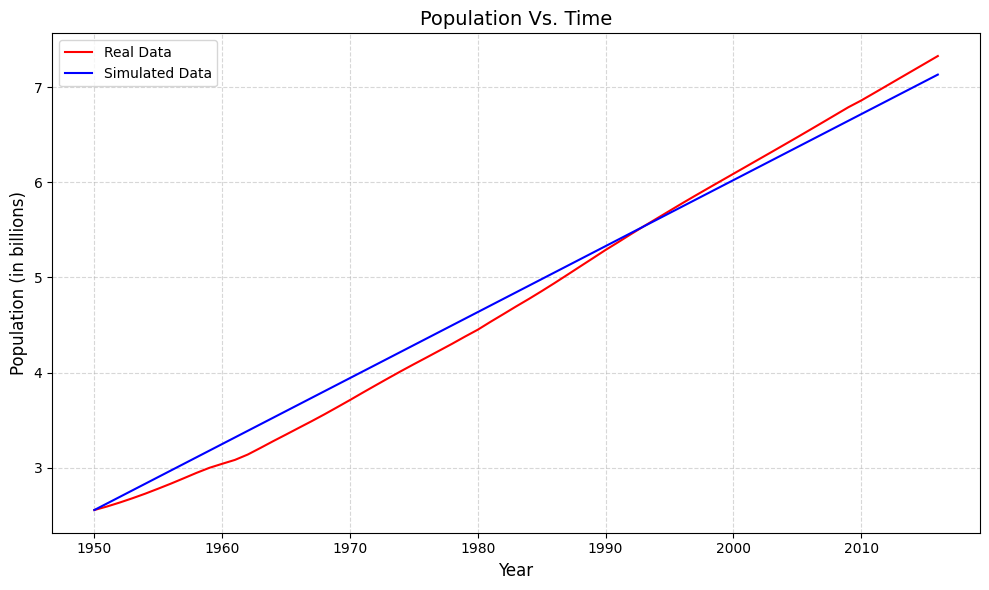

In [28]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_linear_time, initial_state, cf_linear_time)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

[Return to Top](#Notebook-Start)

<a name="Nonlinear"></a>

---

<font size = 6> <b> 4. Non-Linear Change Functions</b> </font>

---

<font size = 5> <b> 4.1 Proportional Growth Model </b> </font>

In the previous version we simulated a model of world population with
constant growth. Our first stab at a model was not great, but with some iteration in the exercises we brought our loss down to about 0.16 billion.  Should we stop there?

 <br>

It's tempting, but there's more to understanding data than just fitting the curve.  If you think about the nature of population, a couple things might be bothering you:

* According to a constant growth model, world population would keep growing at the same rate forever, and that does not seem reasonable.  Even more, the model suggests that this rate of growth would be the same even if the population were tiny.  Somethings not quite right...

* There is no obvious mechanism that would cause population growth to be constant from year to year. Changes in population are determined by the fraction of people who die and the fraction of people who give birth, so we expect them to depend on the current population.

As you can see, fitting a curve to data can be a first step understanding data, but it doesn't really *explain* what is happening in the system.  As we iterate, let's look for a model that might both fit the data better and make more explanatory sense.

<br>

<b>Birth and death rates</b>

The biggest problem with the constant growth model is that it doesn't
make any sense.

<br>


It makes more sense to think of growth and decline in terms of *rates*: some percentage of the population will give birth each year, and a different percentage will die.  

<br>

When we run the simulation, for each time step, we will use the parameter `birth_rate` to compute the number of births, and `death_rate` to compute the number of deaths.


<br>

While `annual_growth` and `shift_constant` were the key parameters for the linear model, `birth_rate` and `death_rate` will be the key parameters here, and we'll need to find the values that best fit the data.  For the death rate, I'll use 7.7 deaths per 1000 people, which was roughly the global death rate in 2020.

<br>

What about the birth rate?  Start with a thought experiment: If both the birth and death rates were 7.7 births per 1000 people, what would happen to the population?  But the population is growing, so we know the birth rate needs to be higher than 7.7. We'll start with 8.0, and rerun the model until it fits the data as closely as possible:


<center>$\rule$</center>

<font size = 5> <b> 4.2 Define Parameters for a Proportional Growth Simulation </b> </font>

In [172]:
##=============================================================================================##
## Set the Proportional Simulation Parameters:                                                 ##
##=============================================================================================##

# Set the end year:

end_year = 2016

# Step Size:

step_size = 1 # year

# Coefficients:

# Birth Rate:

birth_rate = 8.0 / 1000

# Death Rate:

death_rate = 7.7 / 1000

coeffs = [birth_rate - death_rate]

# Store the parameters in a dictionary:

parameters_prop = pd.Series({
    "End Year"     : end_year,
    "Step Size"    : step_size,
    "Coefficients" : coeffs
})

parameters_prop.name = 'value'

display_dataframes([parameters_prop],["Parameters Proportional Growth"])

,value
End Year,2016
Step Size,1
Coefficients,[0.0002999999999999999]


<font size = 5> <b> 4.3 Define a Proportional Change Function </b> </font>

In [178]:
##=============================================================================================##
## Define the Proportional Growth Change Function:                                             ##
##=============================================================================================##

def cf_prop(state, cf_params, step_size):

  # Unpack the parameters:

  growth_rate = cf_params.loc['Coefficients'][0]

  # Get the current population:

  population = state['Population']

  # Update the population based on the time step size and the polynomial coefficients

  state['Population'] += population * growth_rate

  # Update the simulation time:

  state['Year'] += step_size

  # Return the updated system state:

  return state

<center>$\rule$</center>

<font size = 5> <b> 4.3 Run The Simulation With A Proportional Growth Function </b> </font>

,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.558396,1951.0
2,2.559163,1952.0
3,2.559931,1953.0


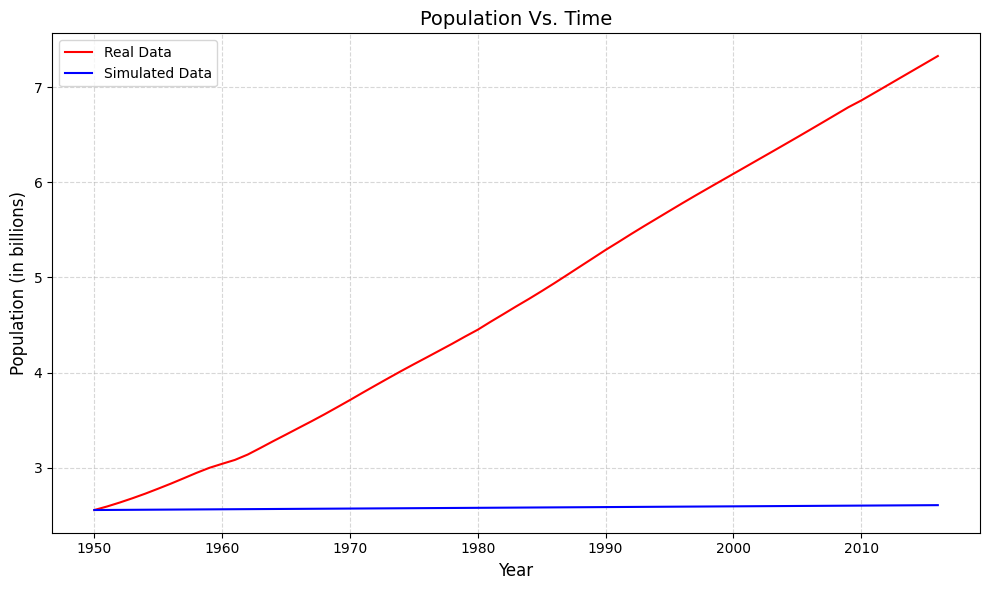

In [179]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_prop, initial_state, cf_prop)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

Clearly, the birth rate that we guessed was too low. Our simulation model is far off from the real data. Let's find the best birth rate.

<center>$\rule$</center>

<font size = 5> <b> 4.4 Finding the Best-Fit Birth Rate </b> </font>

In [182]:
##=============================================================================================##
## Create a List of Slopes:                                                                    ##
##=============================================================================================##

# Set the first slope to test:

first_rate = 8 / 1000

# Set the last slope to test:

last_rate = 8 / 100

# Set the number of slopes to test:

n_rates = 100

# Create a numpy array of slopes:

rates = np.linspace(first_rate, last_rate, n_rates)

##=============================================================================================##
## Loop Through Slope Values:                                                                  ##
##=============================================================================================##

# Death Rate:

death_rate = 7.7 / 1000

# Create a list to store the loss values:

loss_list = []

for birth_rate in rates:

  coeffs = [birth_rate - death_rate]

  # Generate the parameters Series:

  parameters_prop = pd.Series({
    "End Year"     : end_year,
    "Step Size"    : step_size,
    "Coefficients" : coeffs
  })

  # Run the simulation:

  simulation_history = run_simulation(parameters_prop, initial_state, cf_prop)

  # Analyze the simulation output:

  loss = analyze_simulation(simulation_history, X, y, plot_data = False, display_data = False)

  # Store the current loss:

  loss_list.append(loss)

##=============================================================================================##
## Store Slopes and Loss in DataFrame:                                                         ##
##=============================================================================================##

rate_loss_df = pd.DataFrame({"Rate" : rates, "Loss" : loss_list})

# Display the DataFrame:

display_dataframes([rate_loss_df], ["Rate Loss DataFrame"])

##=============================================================================================##
## Use the Query Function to Get the Slope with the Smallest Loss:                             ##
##=============================================================================================##

best_rate = rate_loss_df.query('Loss == Loss.min()')['Rate'].values[0]
best_loss = rate_loss_df.query('Loss == Loss.min()')['Loss'].values[0]

print()
print("Best-Fit Rate: ", np.round(best_rate, 5))
print("Best-Fit Loss:", np.round(best_loss, 5))

,Rate,Loss
0,0.008000,2.627215
1,0.008727,2.553816
2,0.009455,2.477721
3,0.010182,2.398824
4,0.010909,2.317018



Best-Fit Rate:  0.02473
Best-Fit Loss: 0.1859


It looks like, our best-fit birth rate is 24.73 / 1000. Let's run that simulation and see what our results look like.

In [183]:
##=============================================================================================##
## Set the Proportional Simulation Parameters:                                                 ##
##=============================================================================================##

# Set the end year:

end_year = 2016

# Step Size:

step_size = 1 # year

# Coefficients:

# Birth Rate:

birth_rate = 24.73 / 1000

# Death Rate:

death_rate = 7.7 / 1000

coeffs = [birth_rate - death_rate]

# Store the parameters in a dictionary:

parameters_prop = pd.Series({
    "End Year"     : end_year,
    "Step Size"    : step_size,
    "Coefficients" : coeffs
})

parameters_prop.name = 'value'

display_dataframes([parameters_prop],["Parameters Proportional Growth"])

,value
End Year,2016
Step Size,1
Coefficients,[0.017030000000000003]


,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.601185,1951.0
2,2.645483,1952.0
3,2.690536,1953.0


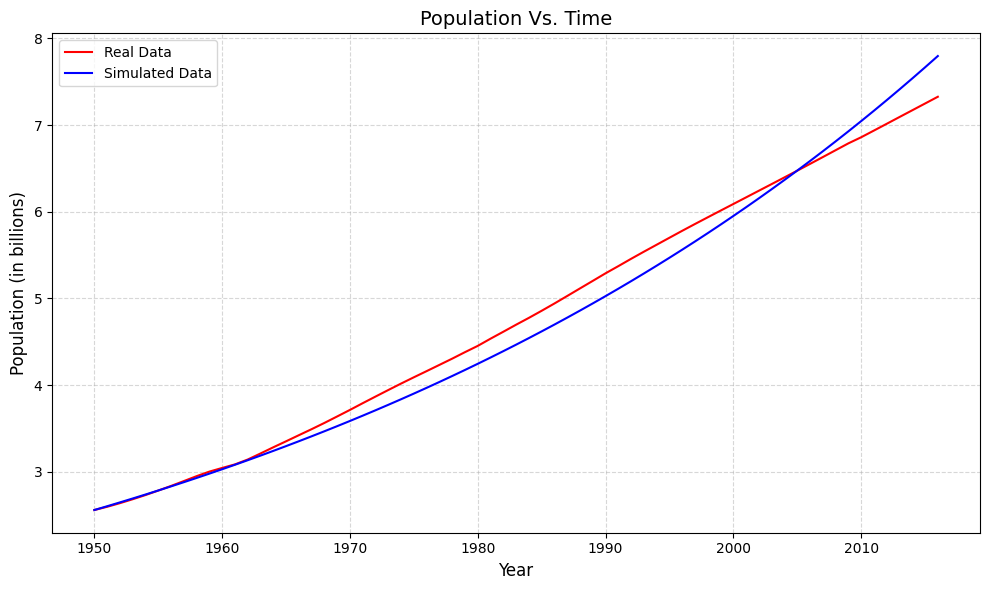

In [184]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_prop, initial_state, cf_prop)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

While this version of the model is more physical than the straight linear-time model, it's fit is worse! Clearly we need to keep iterating our model.

[Return to Top](#Notebook-Start)

<a name="Polynomial"></a>

---

<font size = 6> <b> 5. Polynomial Growth</b> </font>

---

<font size = 5> <b> 5.1 Define a Polynomial-Population Change Function </b> </font>

In [185]:
##=============================================================================================##
## Define the Linear Change Function:                                                          ##
##=============================================================================================##

def cf_poly(state, cf_params, step_size):

  # Unpack the parameters:

  coeffs = cf_params.loc['Coefficients']

  # Set the Polynomial Order:

  order = len(coeffs)

  # Get the current population:

  population = state['Population']

  # Update the population based on its current value and the polynomial coefficients

  for i in range(0, order):

    state['Population'] += coeffs[i] * (population ** (i + 1))

  # Update the simulation time:

  state['Year'] += step_size

  # Return the updated system state:

  return state

<font size = 5> <b> 5.2 Quadratic Growth Model </b> </font>

Now, let's use this new setup to create a quadratic growth rate and see if we get a better result.

In [187]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the end year:

end_year = 2016

# Step Size:

step_size = 1 # year

# Coefficients:

coeffs = [25 / 1000, -1.8 / 1000] # Guesses

# Store the parameters in a dictionary:

parameters_quad = pd.Series({
    "End Year"     : end_year,
    "Step Size"    : step_size,
    "Coefficients" : coeffs
})

parameters_quad.name = 'value'

display_dataframes([parameters_quad],["Quadratic Growth Parameters"])

,value
End Year,2016
Step Size,1
Coefficients,"[0.025, -0.0018]"


,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.609795,1951.0
2,2.662780,1952.0
3,2.716587,1953.0


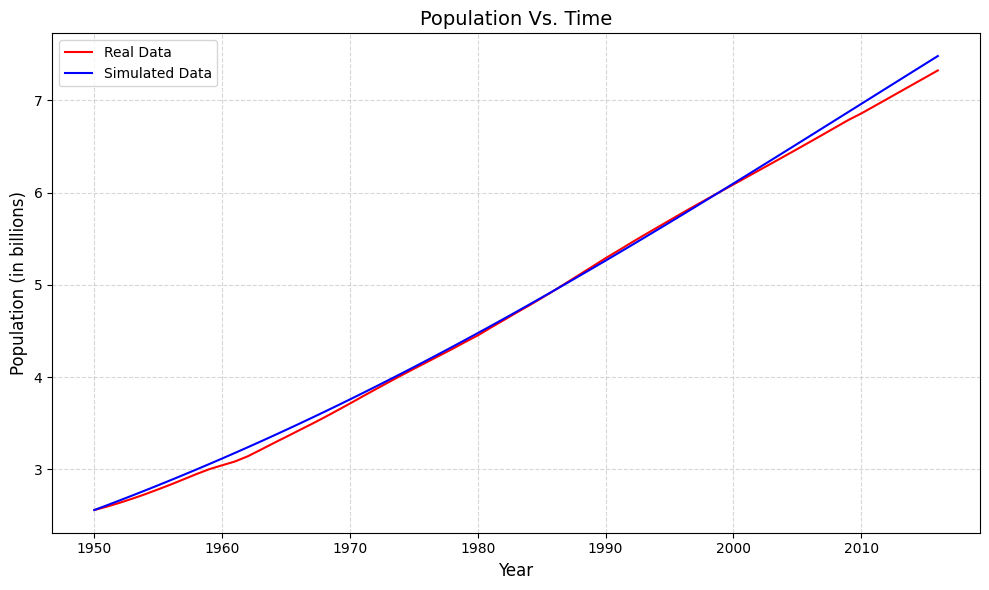

In [188]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_quad, initial_state, cf_poly)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

The quadratic growth model fits the data well over the whole range, with just a bit of space between them in the 1960s.

<br>

It is not entirely surprising that the quadratic model fits better than the
constant and proportional models, because it has two parameters we can
choose where the other models have only one. In general, the more
parameters you have to play with, the better you should expect the model
to fit.

<br>

Be careful, though.  While choosing a really complex function for a curve fit might give you an accurate fit, its explanatory usefulness can suffer: what do all of those coefficients represent in the physical system?  In the proportional model we know that the <b>growth rate</b> meant the difference between the birth and the death rates. But what do the two coefficients in the quadratic model *mean* here?

<br>

In this case, the quadratic model might be a good choice for physical reasons, too: that is, there is a legitimate reason to expect the relationship between growth and population to have this form.  To understand why, let's look at net growth as a function of population.

<font size = 5> <b> 5.3 Investigating net growth in a quadratic system </b> </font>

Let's plot the relationship between growth and population in the quadratic model.  To do this, we'll make an array of 101 populations from 0 to 15 billion.  In the past, when we wanted an object that contained a list of numbers, we used `range`.  But `range` only works with integers.  To get a sequence of non-integer values, we can use `linspace`, which is defined in the NumPy library:

In [190]:
pop_array = np.linspace(0, 15, 101)

display(pop_array)

array([ 0.  ,  0.15,  0.3 ,  0.45,  0.6 ,  0.75,  0.9 ,  1.05,  1.2 ,
        1.35,  1.5 ,  1.65,  1.8 ,  1.95,  2.1 ,  2.25,  2.4 ,  2.55,
        2.7 ,  2.85,  3.  ,  3.15,  3.3 ,  3.45,  3.6 ,  3.75,  3.9 ,
        4.05,  4.2 ,  4.35,  4.5 ,  4.65,  4.8 ,  4.95,  5.1 ,  5.25,
        5.4 ,  5.55,  5.7 ,  5.85,  6.  ,  6.15,  6.3 ,  6.45,  6.6 ,
        6.75,  6.9 ,  7.05,  7.2 ,  7.35,  7.5 ,  7.65,  7.8 ,  7.95,
        8.1 ,  8.25,  8.4 ,  8.55,  8.7 ,  8.85,  9.  ,  9.15,  9.3 ,
        9.45,  9.6 ,  9.75,  9.9 , 10.05, 10.2 , 10.35, 10.5 , 10.65,
       10.8 , 10.95, 11.1 , 11.25, 11.4 , 11.55, 11.7 , 11.85, 12.  ,
       12.15, 12.3 , 12.45, 12.6 , 12.75, 12.9 , 13.05, 13.2 , 13.35,
       13.5 , 13.65, 13.8 , 13.95, 14.1 , 14.25, 14.4 , 14.55, 14.7 ,
       14.85, 15.  ])

Now we'll use the quadratic model to compute net growth for each population, and create a `Series` that holds the relationship between population and net growth for the quadratic model.  

<br>

We can add and multiply arrays by integers in the same way we multiplied `Series` (note: to add arrays, they must have the same number of elements):

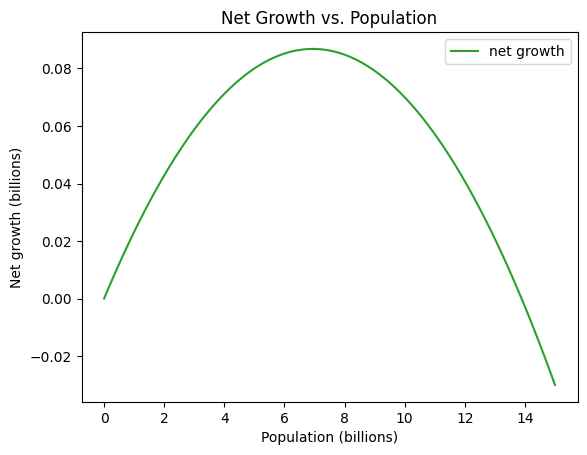

In [193]:
# Calculate the annual growth for all populations between 0 and 15 billion
growth_array = (parameters_quad['Coefficients'][0] * pop_array +
                parameters_quad['Coefficients'][1] * pop_array**2)

# Put this is a Series with populations as the index and the growth
# for that population as the values
quad_net_growth = pd.Series(data=growth_array,index=pop_array)

# Plot the growth:

quad_net_growth.plot(label='net growth', color='C2',
                     xlabel='Population (billions)',
                     ylabel='Net growth (billions)',
                     title='Net Growth vs. Population',
                    legend=True);

<font size = 5> <b> 5.4 Finding Equilibrium </b> </font>

Looking at the plot above tells us several interesting things.  First, with these parameters, the peak growth rate happens when the population is between 7-8 billion.  Second, we can see a point where growth is 0.  The *equilibrium point* is the population at which net population growth, $\Delta p$, is 0.

<br>

We can compute it by finding the roots, or zeros, of this equation:

<br>

$$\Delta p = \alpha p + \beta p^2$$

<br>

where $\alpha$ and $\beta$ are the parameters of the model.
If rewrite the right hand side like this:

<br>

$$\Delta p = p (\alpha + \beta p)$$
<br>

we can see that net growth $\Delta p$ is zero when either of the factors on the right hand side are zero:
<br>

 $$p=0$$

 $$\alpha + \beta p = 0$$
 <br>


If either of these conditions is true, the population growth is zero.  The first equation tells us that this is true when the population is zero: this solution is called a "trivial" solution, because it is an obvious and not useful solution (of course there is no growth if there are no people!).  The second equation, though, leads to a useful solution if we rearrange the equation:

<br>

$$ p = -\alpha / \beta$$

<br>

This gives us an analytical solution to equilibrium population in our model:

In [194]:
print(- parameters_quad['Coefficients'][0] / parameters_quad['Coefficients'][1])

13.88888888888889


With these parameters, net growth is 0 when the population is about 13.9 billion.

<br>


This equilibrium value is so important to understanding the quadratic model that often we rewrite the equation with a different set of parameters.  In the context of population modeling, the quadratic model is more
conventionally written with the parameters $r$ and $K$, where $K$ is the equilibrium value:

<br>

$$\Delta p = r p (1 - p / K)$$

<br>

This is the same exact mathematical model; it's just a different way to *parameterize* it. If this is true, we can set the two equations as equal:

<br>

$$\Delta P = \alpha p + \beta p^2 = r p (1 - p / K)$$

<br>

By doing a little algebra, we could confirm that $r=\alpha$ and $K=-\alpha/\beta$.

<br>

Why use this more complex form of the equation?  It's easier to understand it as a model! That is, it is easier to interpret the parameters:

* $r$ is the unconstrained growth rate, observed when $p$ is small
* $K$ is the equilibrium point

$K$ is also called the *carrying capacity*, since it indicates the maximum population the environment can sustain.

[Return to Top](#Notebook-Start)

---